# Decision Intelligence — Business Insights Report
This notebook derives actionable business insights from the retail data warehouse, integrating findings from sales analytics, customer segmentation, and product performance to recommend strategic actions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine

# Connect to PostgreSQL
# Credentials are loaded from the .env file in the project root
import os
from dotenv import load_dotenv
load_dotenv(os.path.join(os.path.dirname(os.getcwd()), '.env'))

db_user = os.getenv('POSTGRES_USER', 'postgres')
db_pass = os.getenv('POSTGRES_PASSWORD', 'password')
db_host = os.getenv('POSTGRES_HOST', 'localhost')
db_port = os.getenv('POSTGRES_PORT', '5432')
db_name = os.getenv('POSTGRES_DB', 'retail_dw')
engine = create_engine(f'postgresql://{db_user}:{db_pass}@{db_host}:{db_port}/{db_name}')

print("Connected to retail_dw database.")
print("Loading data for Decision Intelligence analysis...")

Connected to retail_dw database.
Loading data for Decision Intelligence analysis...


## 1. Regional Performance Analysis
Identify high-performing and underperforming regions to guide resource allocation and marketing strategy.

REGIONAL PERFORMANCE SUMMARY

--- West ---
  Total Revenue      : $744,293.54
  Total Orders       : 3,160
  Total Units Sold   : 3,160
  Avg Order Value    : $235.54
  Unique Customers   : 255

--- East ---
  Total Revenue      : $606,351.33
  Total Orders       : 2,709
  Total Units Sold   : 2,709
  Avg Order Value    : $223.83
  Unique Customers   : 220

--- Central ---
  Total Revenue      : $514,251.40
  Total Orders       : 2,334
  Total Units Sold   : 2,334
  Avg Order Value    : $220.33
  Unique Customers   : 184

--- South ---
  Total Revenue      : $396,640.70
  Total Orders       : 1,597
  Total Units Sold   : 1,597
  Avg Order Value    : $248.37
  Unique Customers   : 134


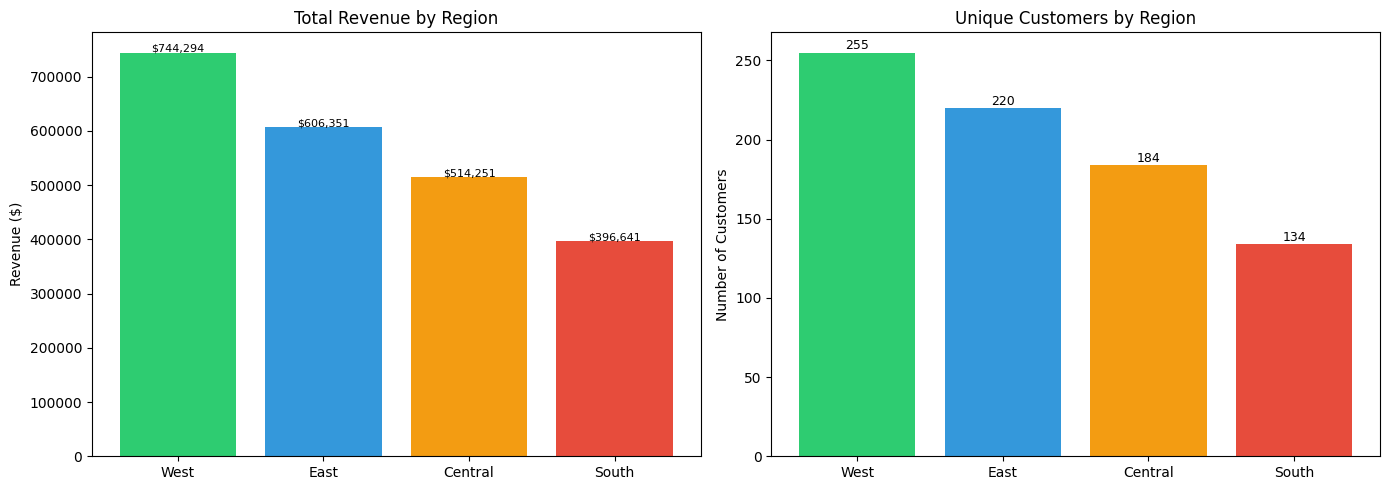

In [2]:
# === REGIONAL PERFORMANCE ANALYSIS ===
query_region = """
    SELECT 
        c.region,
        COUNT(DISTINCT f.sale_id) AS total_orders,
        SUM(f.quantity) AS total_units_sold,
        SUM(f.revenue) AS total_revenue,
        AVG(f.revenue) AS avg_order_value,
        COUNT(DISTINCT f.customer_id) AS unique_customers
    FROM fact_sales f
    JOIN dim_customer c ON f.customer_id = c.customer_id
    GROUP BY c.region
    ORDER BY total_revenue DESC
"""
df_region = pd.read_sql(query_region, engine)

print("=" * 60)
print("REGIONAL PERFORMANCE SUMMARY")
print("=" * 60)
for _, row in df_region.iterrows():
    print(f"\n--- {row['region']} ---")
    print(f"  Total Revenue      : ${row['total_revenue']:,.2f}")
    print(f"  Total Orders       : {row['total_orders']:,}")
    print(f"  Total Units Sold   : {row['total_units_sold']:,}")
    print(f"  Avg Order Value    : ${row['avg_order_value']:,.2f}")
    print(f"  Unique Customers   : {row['unique_customers']:,}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c']

axes[0].bar(df_region['region'], df_region['total_revenue'], color=colors[:len(df_region)])
axes[0].set_title('Total Revenue by Region')
axes[0].set_ylabel('Revenue ($)')
axes[0].tick_params(axis='x', rotation=0)
for i, v in enumerate(df_region['total_revenue']):
    axes[0].text(i, v + 1000, f'${v:,.0f}', ha='center', fontsize=8)

axes[1].bar(df_region['region'], df_region['unique_customers'], color=colors[:len(df_region)])
axes[1].set_title('Unique Customers by Region')
axes[1].set_ylabel('Number of Customers')
axes[1].tick_params(axis='x', rotation=0)
for i, v in enumerate(df_region['unique_customers']):
    axes[1].text(i, v + 2, str(v), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## 2. Product Category Trend Analysis
Detect growing and declining product categories over time to guide inventory and marketing decisions.

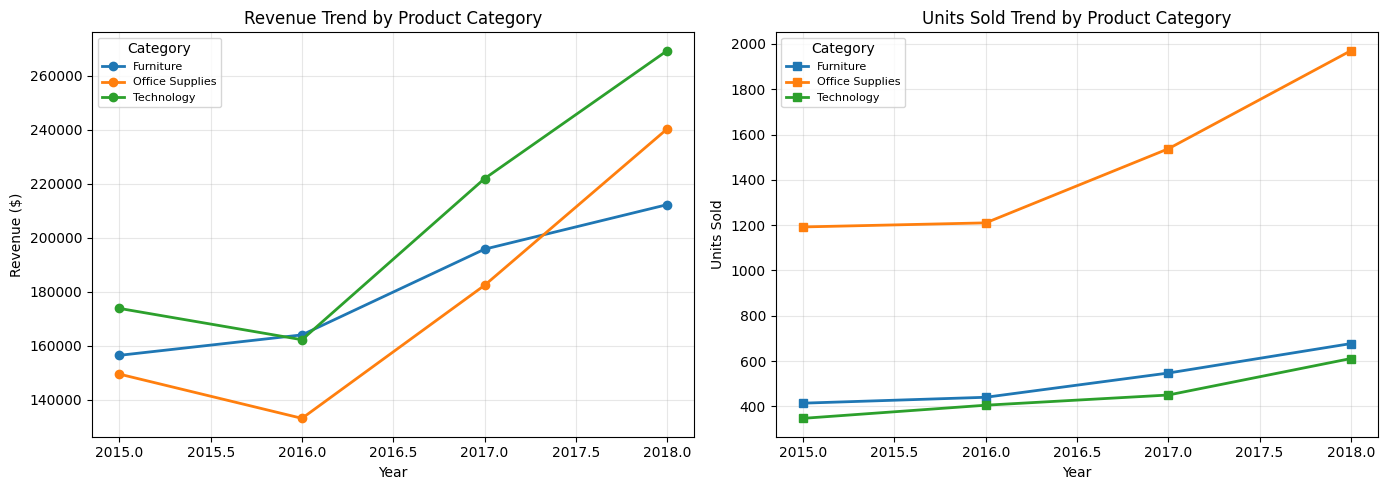

YEAR-OVER-YEAR CATEGORY GROWTH ANALYSIS
  Furniture: GROWING (+35.7% from 2015 to 2018)
  Office Supplies: GROWING (+60.8% from 2015 to 2018)
  Technology: GROWING (+54.9% from 2015 to 2018)


In [3]:
# === PRODUCT CATEGORY TREND ANALYSIS ===
query_product_trend = """
    SELECT 
        d.year,
        p.category,
        SUM(f.revenue) AS total_revenue,
        SUM(f.quantity) AS total_units
    FROM fact_sales f
    JOIN dim_product p ON f.product_id = p.product_id
    JOIN dim_date d ON f.date_id = d.date_id
    GROUP BY d.year, p.category
    ORDER BY d.year ASC, p.category
"""
df_product_trend = pd.read_sql(query_product_trend, engine)

# Pivot for trend visualization
pivot_revenue = df_product_trend.pivot(index='year', columns='category', values='total_revenue').fillna(0)

# Plot trends
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pivot_revenue.plot(ax=axes[0], marker='o', linewidth=2)
axes[0].set_title('Revenue Trend by Product Category')
axes[0].set_ylabel('Revenue ($)')
axes[0].set_xlabel('Year')
axes[0].legend(title='Category', fontsize=8)
axes[0].grid(True, alpha=0.3)

pivot_units = df_product_trend.pivot(index='year', columns='category', values='total_units').fillna(0)
pivot_units.plot(ax=axes[1], marker='s', linewidth=2)
axes[1].set_title('Units Sold Trend by Product Category')
axes[1].set_ylabel('Units Sold')
axes[1].set_xlabel('Year')
axes[1].legend(title='Category', fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Year-over-year growth analysis
print("=" * 60)
print("YEAR-OVER-YEAR CATEGORY GROWTH ANALYSIS")
print("=" * 60)
for category in pivot_revenue.columns:
    values = pivot_revenue[category]
    if len(values) >= 2:
        first_year = values.iloc[0]
        last_year = values.iloc[-1]
        growth = ((last_year - first_year) / first_year * 100) if first_year > 0 else 0
        trend = 'GROWING' if growth > 0 else 'DECLINING'
        print(f"  {category}: {trend} ({growth:+.1f}% from {values.index[0]} to {values.index[-1]})")

## 3. Customer Segment Value Analysis
Analyze customer segments to identify high-value groups and recommend targeting strategies.

CUSTOMER SEGMENT VALUE ANALYSIS

--- Consumer ---
  Customers            : 409
  Total Revenue        : $1,148,060.51
  Revenue per Customer : $2,806.99
  Orders per Customer  : 12.5
  Avg Order Value      : $225.07

--- Corporate ---
  Customers            : 236
  Total Revenue        : $688,494.14
  Revenue per Customer : $2,917.35
  Orders per Customer  : 12.5
  Avg Order Value      : $233.15

--- Home Office ---
  Customers            : 148
  Total Revenue        : $424,982.32
  Revenue per Customer : $2,871.50
  Orders per Customer  : 11.8
  Avg Order Value      : $243.40


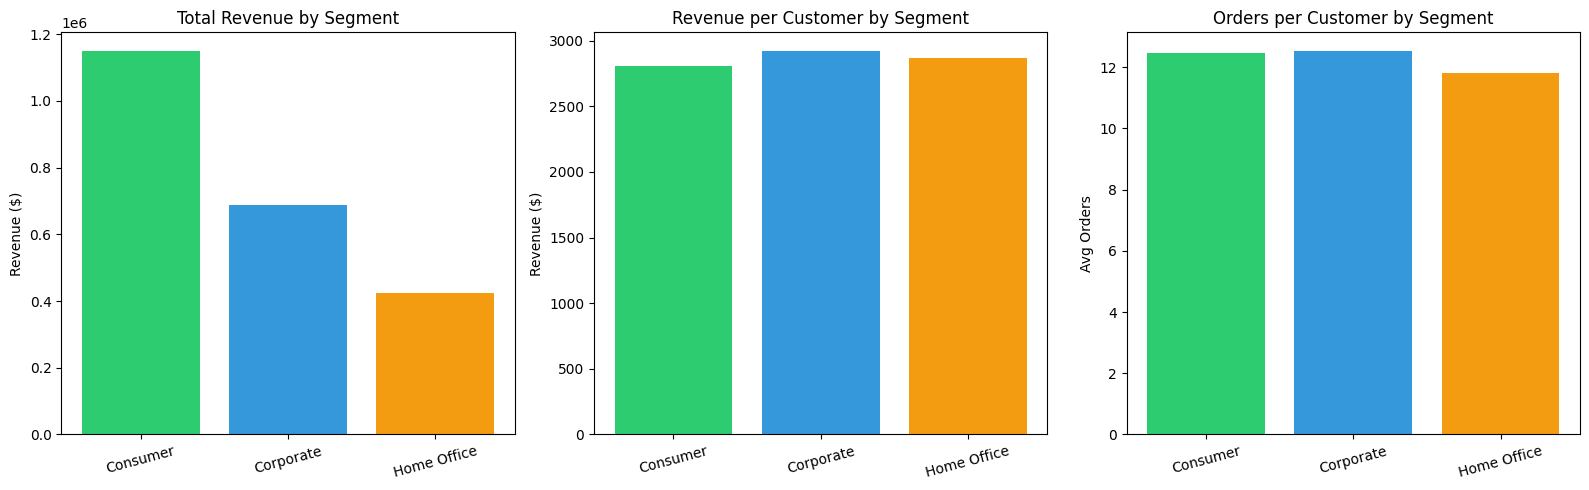

In [4]:
# === CUSTOMER SEGMENT VALUE ANALYSIS ===
query_segment = """
    SELECT 
        c.segment,
        COUNT(DISTINCT c.customer_id) AS customer_count,
        SUM(f.revenue) AS total_revenue,
        AVG(f.revenue) AS avg_order_value,
        COUNT(DISTINCT f.sale_id) AS total_orders
    FROM fact_sales f
    JOIN dim_customer c ON f.customer_id = c.customer_id
    GROUP BY c.segment
    ORDER BY total_revenue DESC
"""
df_segment = pd.read_sql(query_segment, engine)

# Calculate revenue per customer
df_segment['revenue_per_customer'] = df_segment['total_revenue'] / df_segment['customer_count']
df_segment['orders_per_customer'] = df_segment['total_orders'] / df_segment['customer_count']

print("=" * 60)
print("CUSTOMER SEGMENT VALUE ANALYSIS")
print("=" * 60)
for _, row in df_segment.iterrows():
    print(f"\n--- {row['segment']} ---")
    print(f"  Customers            : {row['customer_count']:,}")
    print(f"  Total Revenue        : ${row['total_revenue']:,.2f}")
    print(f"  Revenue per Customer : ${row['revenue_per_customer']:,.2f}")
    print(f"  Orders per Customer  : {row['orders_per_customer']:.1f}")
    print(f"  Avg Order Value      : ${row['avg_order_value']:,.2f}")

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

colors = ['#2ecc71', '#3498db', '#f39c12']

axes[0].bar(df_segment['segment'], df_segment['total_revenue'], color=colors[:len(df_segment)])
axes[0].set_title('Total Revenue by Segment')
axes[0].set_ylabel('Revenue ($)')
axes[0].tick_params(axis='x', rotation=15)

axes[1].bar(df_segment['segment'], df_segment['revenue_per_customer'], color=colors[:len(df_segment)])
axes[1].set_title('Revenue per Customer by Segment')
axes[1].set_ylabel('Revenue ($)')
axes[1].tick_params(axis='x', rotation=15)

axes[2].bar(df_segment['segment'], df_segment['orders_per_customer'], color=colors[:len(df_segment)])
axes[2].set_title('Orders per Customer by Segment')
axes[2].set_ylabel('Avg Orders')
axes[2].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

## 4. Business Action Recommendations
Consolidated actionable insights derived from all analyses above.

In [5]:
# === CONSOLIDATED BUSINESS ACTION RECOMMENDATIONS ===

# Identify top and bottom regions
top_region = df_region.iloc[0]['region']
bottom_region = df_region.iloc[-1]['region']

# Identify top segment
top_segment = df_segment.iloc[0]['segment']

print("=" * 70)
print("DECISION INTELLIGENCE \u2014 BUSINESS ACTION RECOMMENDATIONS")
print("=" * 70)

print(f"""
1. REGIONAL STRATEGY
   \u2022 The {top_region} region is the top performer by revenue.
     -> Analyze what marketing strategies work in {top_region} and
        replicate them in underperforming regions.
   \u2022 The {bottom_region} region has the lowest revenue.
     -> Investigate local market conditions, consider targeted
        promotions, and allocate additional marketing budget.

2. PRODUCT STRATEGY
   \u2022 Monitor declining product categories closely.
     -> Consider product refreshes, pricing adjustments, or
        discontinuation of poor performers.
   \u2022 Growing categories should receive increased inventory
     and marketing support to maximize momentum.

3. CUSTOMER STRATEGY
   \u2022 The '{top_segment}' segment generates the most revenue.
     -> Prioritize retention programs (loyalty rewards, VIP access)
        for this segment.
   \u2022 Implement targeted campaigns to move Mid-Value customers
     into the High-Value tier through upselling and cross-selling.
   \u2022 Deploy re-engagement campaigns for At-Risk customers
     (win-back offers, feedback surveys).

4. FORECASTING & PLANNING
   \u2022 Use ARIMA forecast results to plan inventory procurement
     and budget allocation for the next 6 months.
   \u2022 Regularly retrain the forecasting model with new data
     to maintain prediction accuracy.

5. DATA-DRIVEN CULTURE
   \u2022 Schedule monthly dashboard reviews to track KPIs.
   \u2022 Set up automated alerts for significant deviations
     in revenue, customer churn, or product performance.
""")

print("=" * 70)
print("END OF DECISION INTELLIGENCE REPORT")
print("=" * 70)

DECISION INTELLIGENCE — BUSINESS ACTION RECOMMENDATIONS

1. REGIONAL STRATEGY
   • The West region is the top performer by revenue.
     -> Analyze what marketing strategies work in West and
        replicate them in underperforming regions.
   • The South region has the lowest revenue.
     -> Investigate local market conditions, consider targeted
        promotions, and allocate additional marketing budget.

2. PRODUCT STRATEGY
   • Monitor declining product categories closely.
     -> Consider product refreshes, pricing adjustments, or
        discontinuation of poor performers.
   • Growing categories should receive increased inventory
     and marketing support to maximize momentum.

3. CUSTOMER STRATEGY
   • The 'Consumer' segment generates the most revenue.
     -> Prioritize retention programs (loyalty rewards, VIP access)
        for this segment.
   • Implement targeted campaigns to move Mid-Value customers
     into the High-Value tier through upselling and cross-selling.
  